# Define traits and seed genes for training 


In [4]:
import polars as pl
from pathlib import Path
import numpy as np

In [5]:
data_dir = Path("/home/dnanexus/data_dir")

In [6]:
# ! dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_AM_mac20_EUR.parquet project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_AM_maf1e-3_EUR.parquet -o {data_dir}/baseline_results
# ! dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/phenotypes/corrected_cov_PRS_traits_EUR.parquet -o {data_dir}/
# ! dx download -r ukb-gagneur:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/ -o {data_dir}/

In [7]:
baseline_res = pl.read_parquet(data_dir / "regenie_127phenotypes_lofteeHC_mac20_EUR.parquet")  
baseline_res = baseline_res.with_columns(significant = pl.col("pval_fdr") < 0.05)
significant_baseline = baseline_res.filter(pl.col("significant"))#.filter(pl.col("region").is_in(present_regions['region']))
significant_baseline

region,chr,phenotype,cohort,model,effect,lci_effect,uci_effect,pval,aaf,num_cases,cases_ref,cases_het,cases_alt,num_controls,controls_ref,controls_het,controls_alt,info,pval_fdr,pval_bonf,significant
str,i64,str,str,str,f64,f64,f64,f64,f64,i64,i64,i64,i64,str,str,str,str,str,f64,f64,bool
"""ENSG00000132855""",1,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.46207,-0.612266,-0.311875,1.6422e-9,0.000166,386584,386456,128,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.076632;MAC=128.00…",0.000007,0.003328,true
"""ENSG00000052841""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.807306,-1.19208,-0.422532,0.000039,0.000049,386584,386509,75,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.196317;MAC=38.000…",0.038502,1.0,true
"""ENSG00000110243""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.449444,-0.633744,-0.265144,0.000002,0.00011,386584,386499,85,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.094032;MAC=85.001…",0.003376,1.0,true
"""ENSG00000118137""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-2.60164,-2.94144,-2.26184,6.6771e-51,0.000032,386584,386559,25,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.173370;MAC=25.000…",4.5099e-46,1.3530e-44,true
"""ENSG00000173064""",12,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.873767,-1.24455,-0.502986,0.000004,0.000053,386584,386503,81,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.189177;MAC=41.000…",0.006545,1.0,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000182095""",7,"""forced_expiratory_volume_in_1s…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.860502,-1.2525,-0.468501,0.000017,0.00003,405948,405899,49,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.200004;MAC=24.500…",0.02095,1.0,true
"""ENSG00000164741""",8,"""forced_expiratory_volume_in_1s…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.642983,-0.947885,-0.338081,0.000036,0.00005,405948,405867,81,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.155565;MAC=40.500…",0.036208,1.0,true
"""ENSG00000205189""",8,"""forced_expiratory_volume_in_1s…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.635227,-0.942006,-0.328447,0.000049,0.000025,405948,405928,20,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.156523;MAC=20.000…",0.045581,1.0,true


In [8]:
# Download phenotypes: covariates and PRS corrected
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/phenotypes/corrected_cov_PRS_traits_EUR.parquet -o /home/dnanexus/data_dir/

phenos = pl.read_parquet('/home/dnanexus/data_dir/corrected_cov_PRS_traits_EUR.parquet')
phenos = (
    phenos
    .drop([c for c in phenos.columns if 'jurgens' in c])
)

phenos

Error: path "/home/dnanexus/data_dir/corrected_cov_PRS_traits_EUR.parquet"
already exists but -f/--overwrite was not set


individual,arm_fat_percentage_left_int,basophill_count_int,high_light_scatter_reticulocyte_count_int,arm_fatfree_mass_left_int,creactive_protein_int,reticulocyte_count_int,glucose_int,heel_bone_mineral_density_bmd_tscore_automated_right_int,hand_grip_strength_right_int,trunk_fatfree_mass_int,fluid_intelligence_score_int,body_mass_index_bmi_int,eosinophill_percentage_int,forced_expiratory_volume_in_1second_fev1_best_measure_int,red_blood_cell_erythrocyte_count_int,leg_fatfree_mass_left_int,waist_circumference_int,standing_height_int,arm_fatfree_mass_right_int,seated_height_int,oestradiol_int,apolipoprotein_a_int,heel_bone_mineral_density_bmd_left_int,arm_fat_mass_right_int,stroke_volume_during_pwa_int,igf1_int,body_fat_percentage_int,age_when_last_used_oral_contraceptive_pill_int,apolipoprotein_b_int,gamma_glutamyltransferase_int,neutrophill_count_int,immature_reticulocyte_fraction_int,leg_fat_percentage_left_int,glycated_haemoglobin_hba1c_int,total_bilirubin_int,sitting_height_int,…,tortuosity_density_of_artery_right,distance_between_optic_disk_and_fovea_left,fractal_dimension_of_vein_right,tortuosity_density_of_artery_left,concavity_of_the_papillomacular_arterial_arcade_right,angle_between_optic_disk_and_fovea_left,fovea_centroid_y_coordinate__right,fovea_centroid_y_coordinate__left,concavity_of_the_papillomacular_arterial_arcade_left,r_squared_of_model_fit_to_artery_parabola_shape_right,optic_disk_minor_axis_length_left,concavity_of_the_papillomacular_venous_arcade_left,optic_disk_centroid_x_coordinate_right,fovea_centroid_x_coordinate_left,adjusted_optic_disk_major_axis_length_left,combined_fractal_dimension_of_vasculature_left,combined_tortuosity_density_of_vasculature_left,knudtson_central_retinal_venular_equivalent_right,optic_disk_orientation_left,r_squared_of_model_fit_to_venous_parabola_shape_right,fractal_dimension_of_vein_left,optic_disk_orientation_right,distance_between_optic_disk_and_fovea_right,fovea_centroid_x_coordinate_right,adjusted_distance_between_optic_disk_and_fovea_right,r_squared_of_model_fit_to_venous_parabola_shape_left,median_foveal_pixel_intensity_left,optic_disk_centroid_y_coordinate__left,fractal_dimension_of_artery_right,optic_disk_centroid_y_coordinate__right,adjusted_distance_between_optic_disk_and_fovea_left,angle_between_optic_disk_and_fovea_right,combined_tortuosity_density_of_vasculature_right,knudtson_central_retinal_arteriolar_equivalent_left,median_foveal_pixel_intensity_right,knudtson_central_retinal_arteriolar_equivalent_right,adjusted_optic_disk_minor_axis_length_left
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""1000020""",-0.66072,2.897619,-0.884392,-0.719405,-0.309445,-0.85982,-0.73766,null,-0.013968,-0.779708,null,-0.771904,-1.531674,0.060006,-0.010788,-0.706429,-0.786716,-0.560732,-0.727854,-0.327381,null,-0.873931,null,-0.788784,null,0.064183,-0.585133,null,0.937826,-0.707955,1.300824,-0.752744,-0.510343,0.285142,-0.897566,-0.41544,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1000107""",-0.806305,1.615834,-0.456401,0.107505,0.399696,-0.321747,null,null,0.136971,0.203538,null,-0.474691,-0.21631,-0.121623,-0.406341,-0.242606,0.158603,-0.146177,0.38869,-0.770639,-1.37682,null,null,-1.002036,null,0.819744,-1.009343,1.910191,-0.146645,-0.669581,-1.057355,-0.84863,-0.54249,-0.863708,1.233542,-1.70699,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""1000161""",-0.067472,1.150647,1.003713,-0.688923,-0.526078,0.481383,0.762378,-0.904707,-0.100593,-0.665781

In [9]:
avail_phenos = list(set(phenos.columns) & set(baseline_res['phenotype']))
len(avail_phenos), len(set(baseline_res['phenotype'].unique()))
len(avail_phenos)

127

In [10]:
# len(set(significant_baseline['region']) - set(present_regions['region'])), len(set(significant_baseline['region']))
len(set(significant_baseline['region'])), len(set(significant_baseline['region']))

(699, 699)

In [11]:
# genes_to_keep = set(present_regions['region']) & set(significant_baseline['region'])
genes_to_keep = set(significant_baseline['region'])
len(genes_to_keep)

699

## Total number of seed genes


In [12]:
significant_baseline.group_by('phenotype').agg(pl.len()).sort('len', descending=True)

phenotype,len
str,u64
"""standing_height_int""",111
"""sitting_height_int""",66
"""mean_corpuscular_haemoglobin_i…",49
"""forced_vital_capacity_fvc_int""",49
"""whole_body_fatfree_mass_int""",45
…,…
"""age_started_wearing_glasses_or…",1
"""age_at_hysterectomy_int""",1
"""stroke_volume_during_pwa_int""",1


In [11]:
# seed_gene_df.write_parquet('seed_genes_genebass.parquet')
# ! dx upload seed_genes_genebass.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/users/eh/data_for_training/ 

## Overlap of seed genes 


In [13]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


In [14]:
significant_baseline

region,chr,phenotype,cohort,model,effect,lci_effect,uci_effect,pval,aaf,num_cases,cases_ref,cases_het,cases_alt,num_controls,controls_ref,controls_het,controls_alt,info,pval_fdr,pval_bonf,significant
str,i64,str,str,str,f64,f64,f64,f64,f64,i64,i64,i64,i64,str,str,str,str,str,f64,f64,bool
"""ENSG00000132855""",1,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.46207,-0.612266,-0.311875,1.6422e-9,0.000166,386584,386456,128,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.076632;MAC=128.00…",0.000007,0.003328,true
"""ENSG00000052841""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.807306,-1.19208,-0.422532,0.000039,0.000049,386584,386509,75,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.196317;MAC=38.000…",0.038502,1.0,true
"""ENSG00000110243""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.449444,-0.633744,-0.265144,0.000002,0.00011,386584,386499,85,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.094032;MAC=85.001…",0.003376,1.0,true
"""ENSG00000118137""",11,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-2.60164,-2.94144,-2.26184,6.6771e-51,0.000032,386584,386559,25,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.173370;MAC=25.000…",4.5099e-46,1.3530e-44,true
"""ENSG00000173064""",12,"""apolipoprotein_a_int""","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.873767,-1.24455,-0.502986,0.000004,0.000053,386584,386503,81,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.189177;MAC=41.000…",0.006545,1.0,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000182095""",7,"""forced_expiratory_volume_in_1s…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.860502,-1.2525,-0.468501,0.000017,0.00003,405948,405899,49,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.200004;MAC=24.500…",0.02095,1.0,true
"""ENSG00000164741""",8,"""forced_expiratory_volume_in_1s…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.642983,-0.947885,-0.338081,0.000036,0.00005,405948,405867,81,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.155565;MAC=40.500…",0.036208,1.0,true
"""ENSG00000205189""",8,"""forced_expiratory_volume_in_1s…","""scores_bgen_lofteeHC_mac20""","""ADD-WGR-LR""",-0.635227,-0.942006,-0.328447,0.000049,0.000025,405948,405928,20,0,"""NA""","""NA""","""NA""","""NA""","""REGENIE_SE=0.156523;MAC=20.000…",0.045581,1.0,true


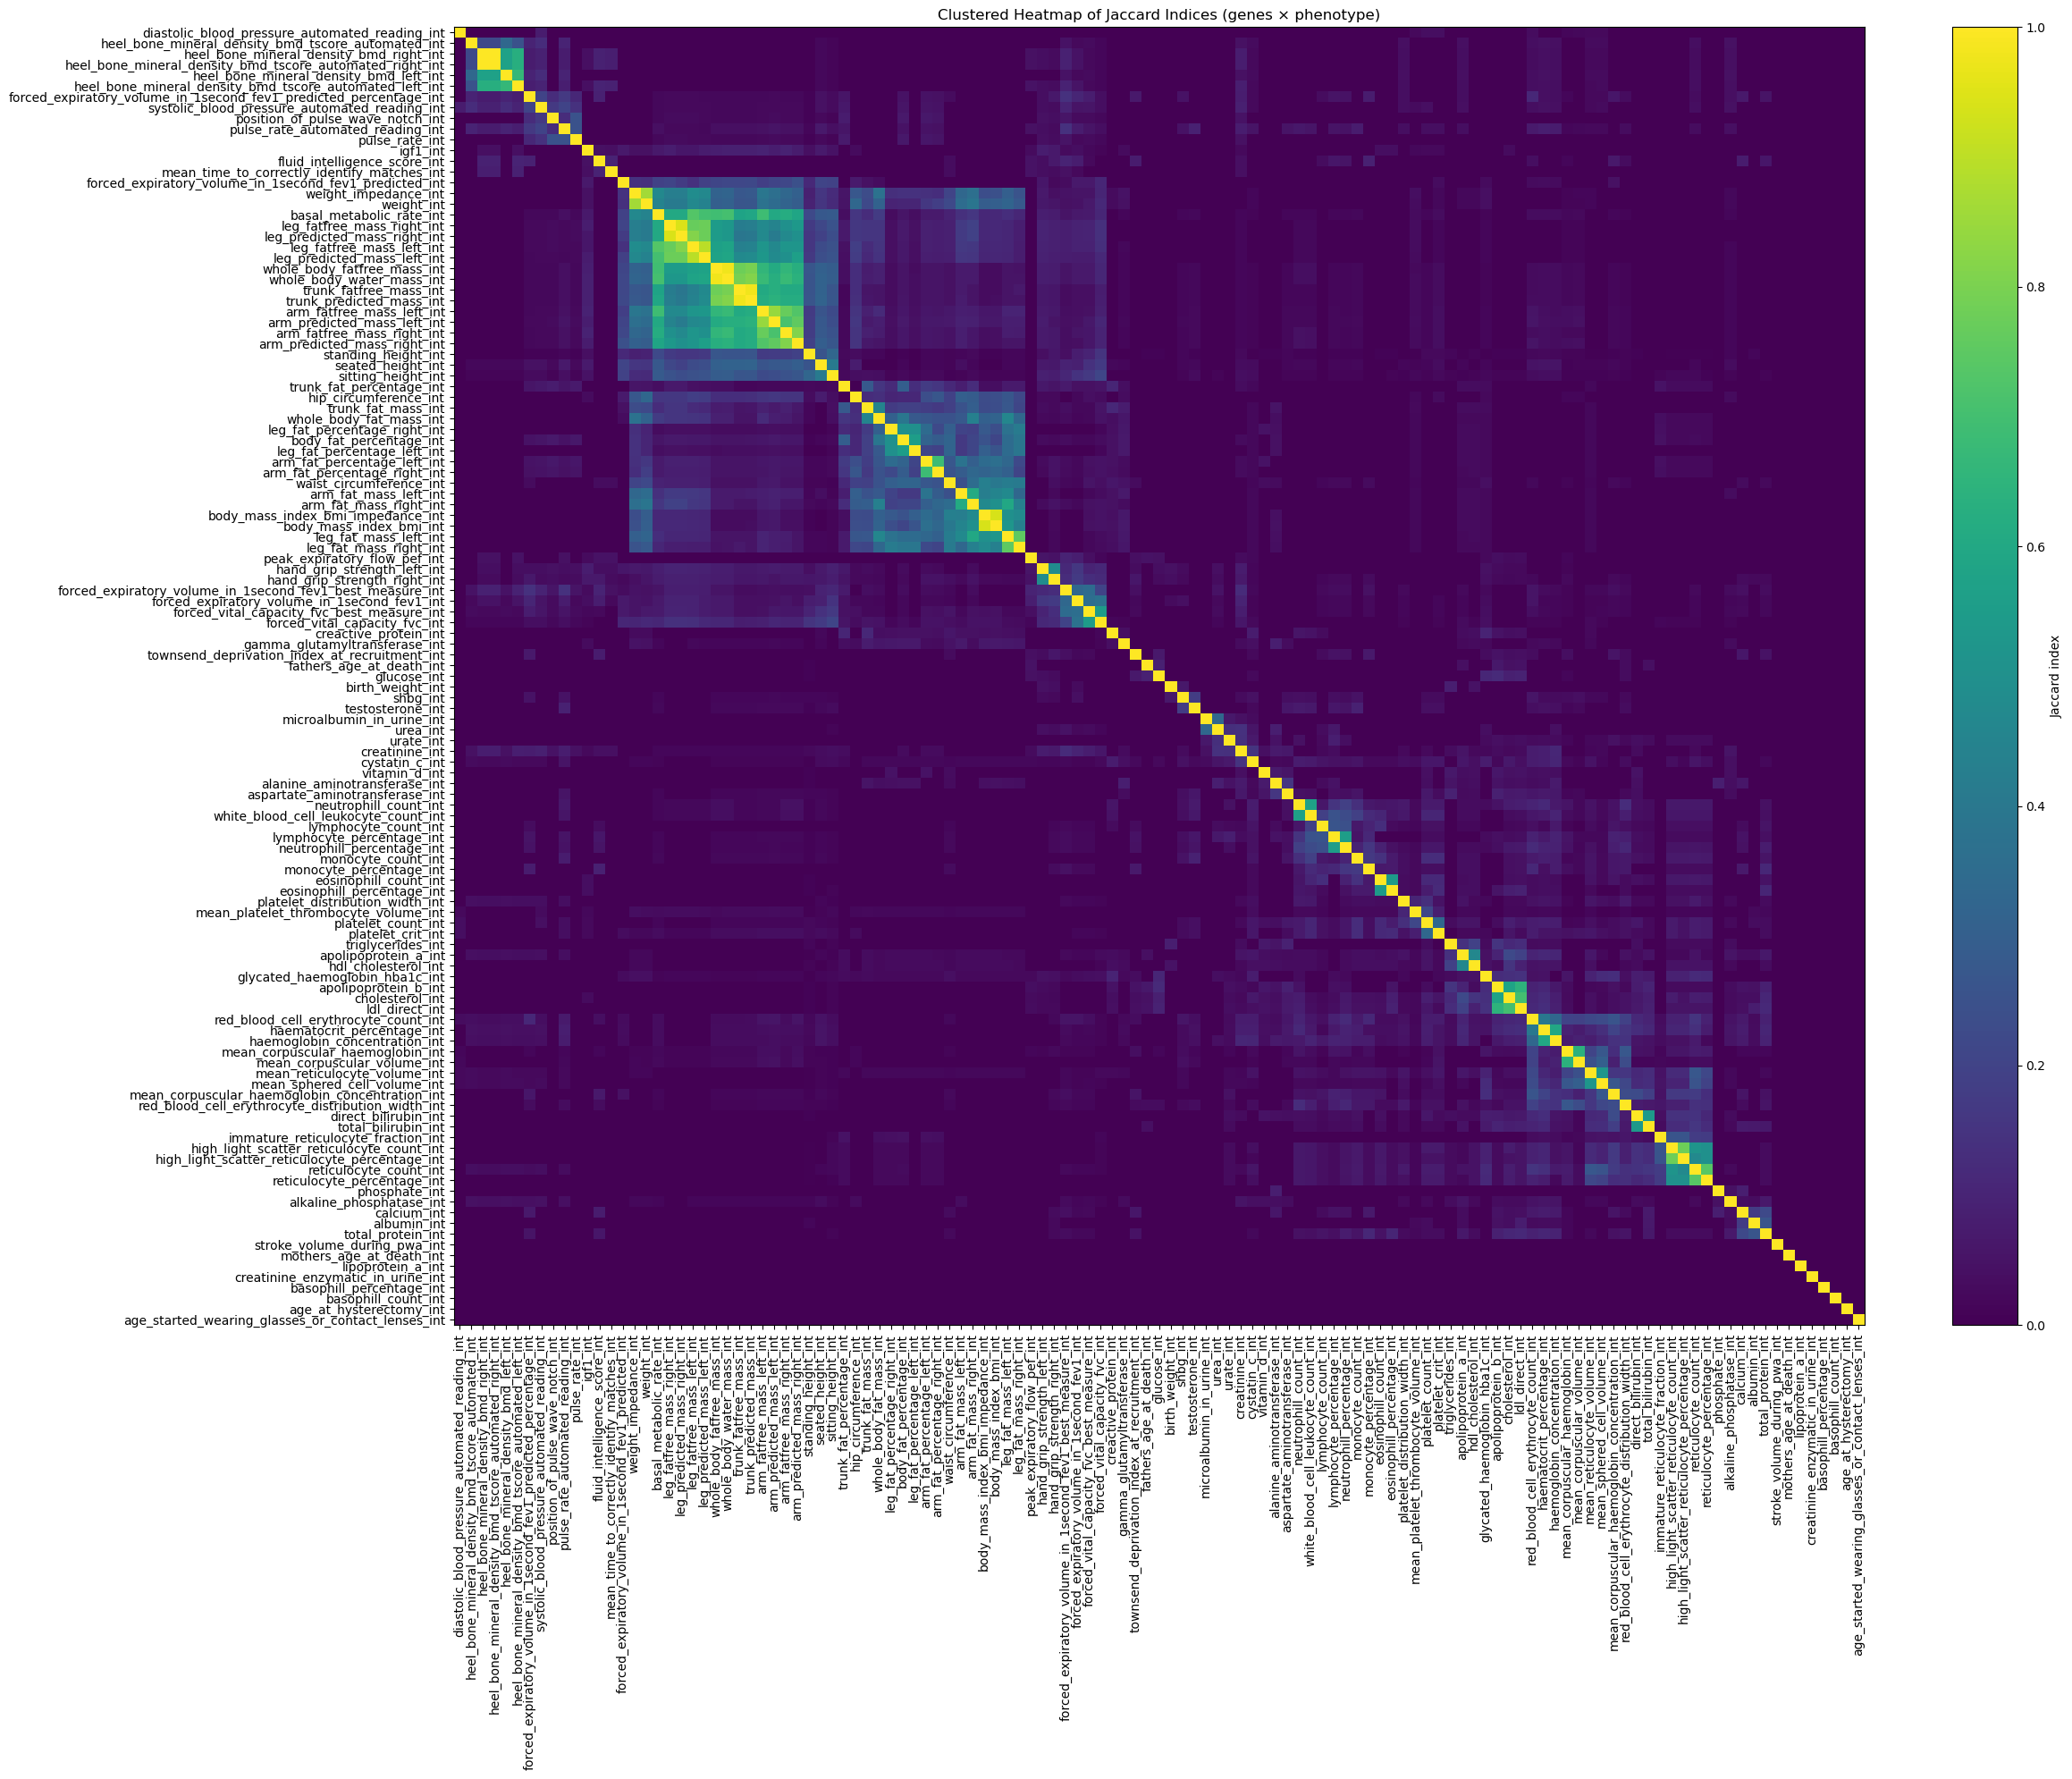

In [15]:
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

base = (
    significant_baseline.select(["phenotype", "region"])
      .drop_nulls()
      .unique()
)

# 2) per-phenotype gene counts
cnt = base.group_by("phenotype").len().rename({"len": "n"})

# 3) intersections: join on gene_id to find shared genes, count per phenotype pair
inter = (
    base.join(base, on="region", suffix="_2")
        .filter(pl.col("phenotype") < pl.col("phenotype_2"))  # keep upper triangle
        .group_by(["phenotype", "phenotype_2"])
        .agg(pl.len().alias("k"))  # |A ∩ B|
)

# 4) all phenotype pairs (including zero-overlap), then compute union and Jaccard
pairs = (
    cnt.join(cnt, how="cross", suffix="_2")
       .filter(pl.col("phenotype") < pl.col("phenotype_2"))
       .rename({
           "phenotype": "p1", "n": "n1",
           "phenotype_2": "p2", "n_2": "n2"
       })
)

jaccard_df = (
    pairs.join(
        inter.rename({"phenotype": "p1", "phenotype_2": "p2"}),
        on=["p1", "p2"],
        how="left",
    )
    .with_columns(pl.col("k").fill_null(0))                         # |A ∩ B|
    .with_columns((pl.col("n1") + pl.col("n2") - pl.col("k")).alias("union"))  # |A ∪ B|
    .with_columns(
        pl.when(pl.col("union") > 0)
          .then(pl.col("k") / pl.col("union"))
          .otherwise(0.0)
          .alias("jaccard")
    )
    .select(["p1", "p2", "jaccard", "k", "union", "n1", "n2"])
    .sort(["p1", "p2"])
)

jaccard_df
# --- Build a symmetric Jaccard matrix (labels x labels) ---
phens = sorted(set(jaccard_df["p1"].to_list()) | set(jaccard_df["p2"].to_list()))
idx = {p: i for i, p in enumerate(phens)}
n = len(phens)

J = np.zeros((n, n), dtype=float)
np.fill_diagonal(J, 1.0)

# fill upper/lower triangle from long-form table
for p1, p2, j in jaccard_df.select(["p1", "p2", "jaccard"]).iter_rows():
    i, k = idx[p1], idx[p2]
    J[i, k] = j
    J[k, i] = j

# --- Cluster using distance = 1 - Jaccard ---
# Guard numeric stability (clip to [0, 1]) and ensure zeros on diagonal
D = 1.0 - np.clip(J, 0.0, 1.0)
np.fill_diagonal(D, 0.0)

# SciPy expects condensed form (upper triangle) for linkage
Z = linkage(squareform(D, checks=False), method="average")
order = leaves_list(Z)

J_ord = J[order][:, order]
labels_ord = [phens[i] for i in order]

# --- Plot clustered heatmap (Matplotlib only) ---
plt.figure(figsize=(25, 20))
im = plt.imshow(J_ord, vmin=0, vmax=1, aspect="auto")
plt.xticks(range(n), labels_ord, rotation=90)
plt.yticks(range(n), labels_ord)
plt.colorbar(im, label="Jaccard index")
plt.title("Clustered Heatmap of Jaccard Indices (genes × phenotype)")
plt.tight_layout()
plt.show()

## Phenotype correlations


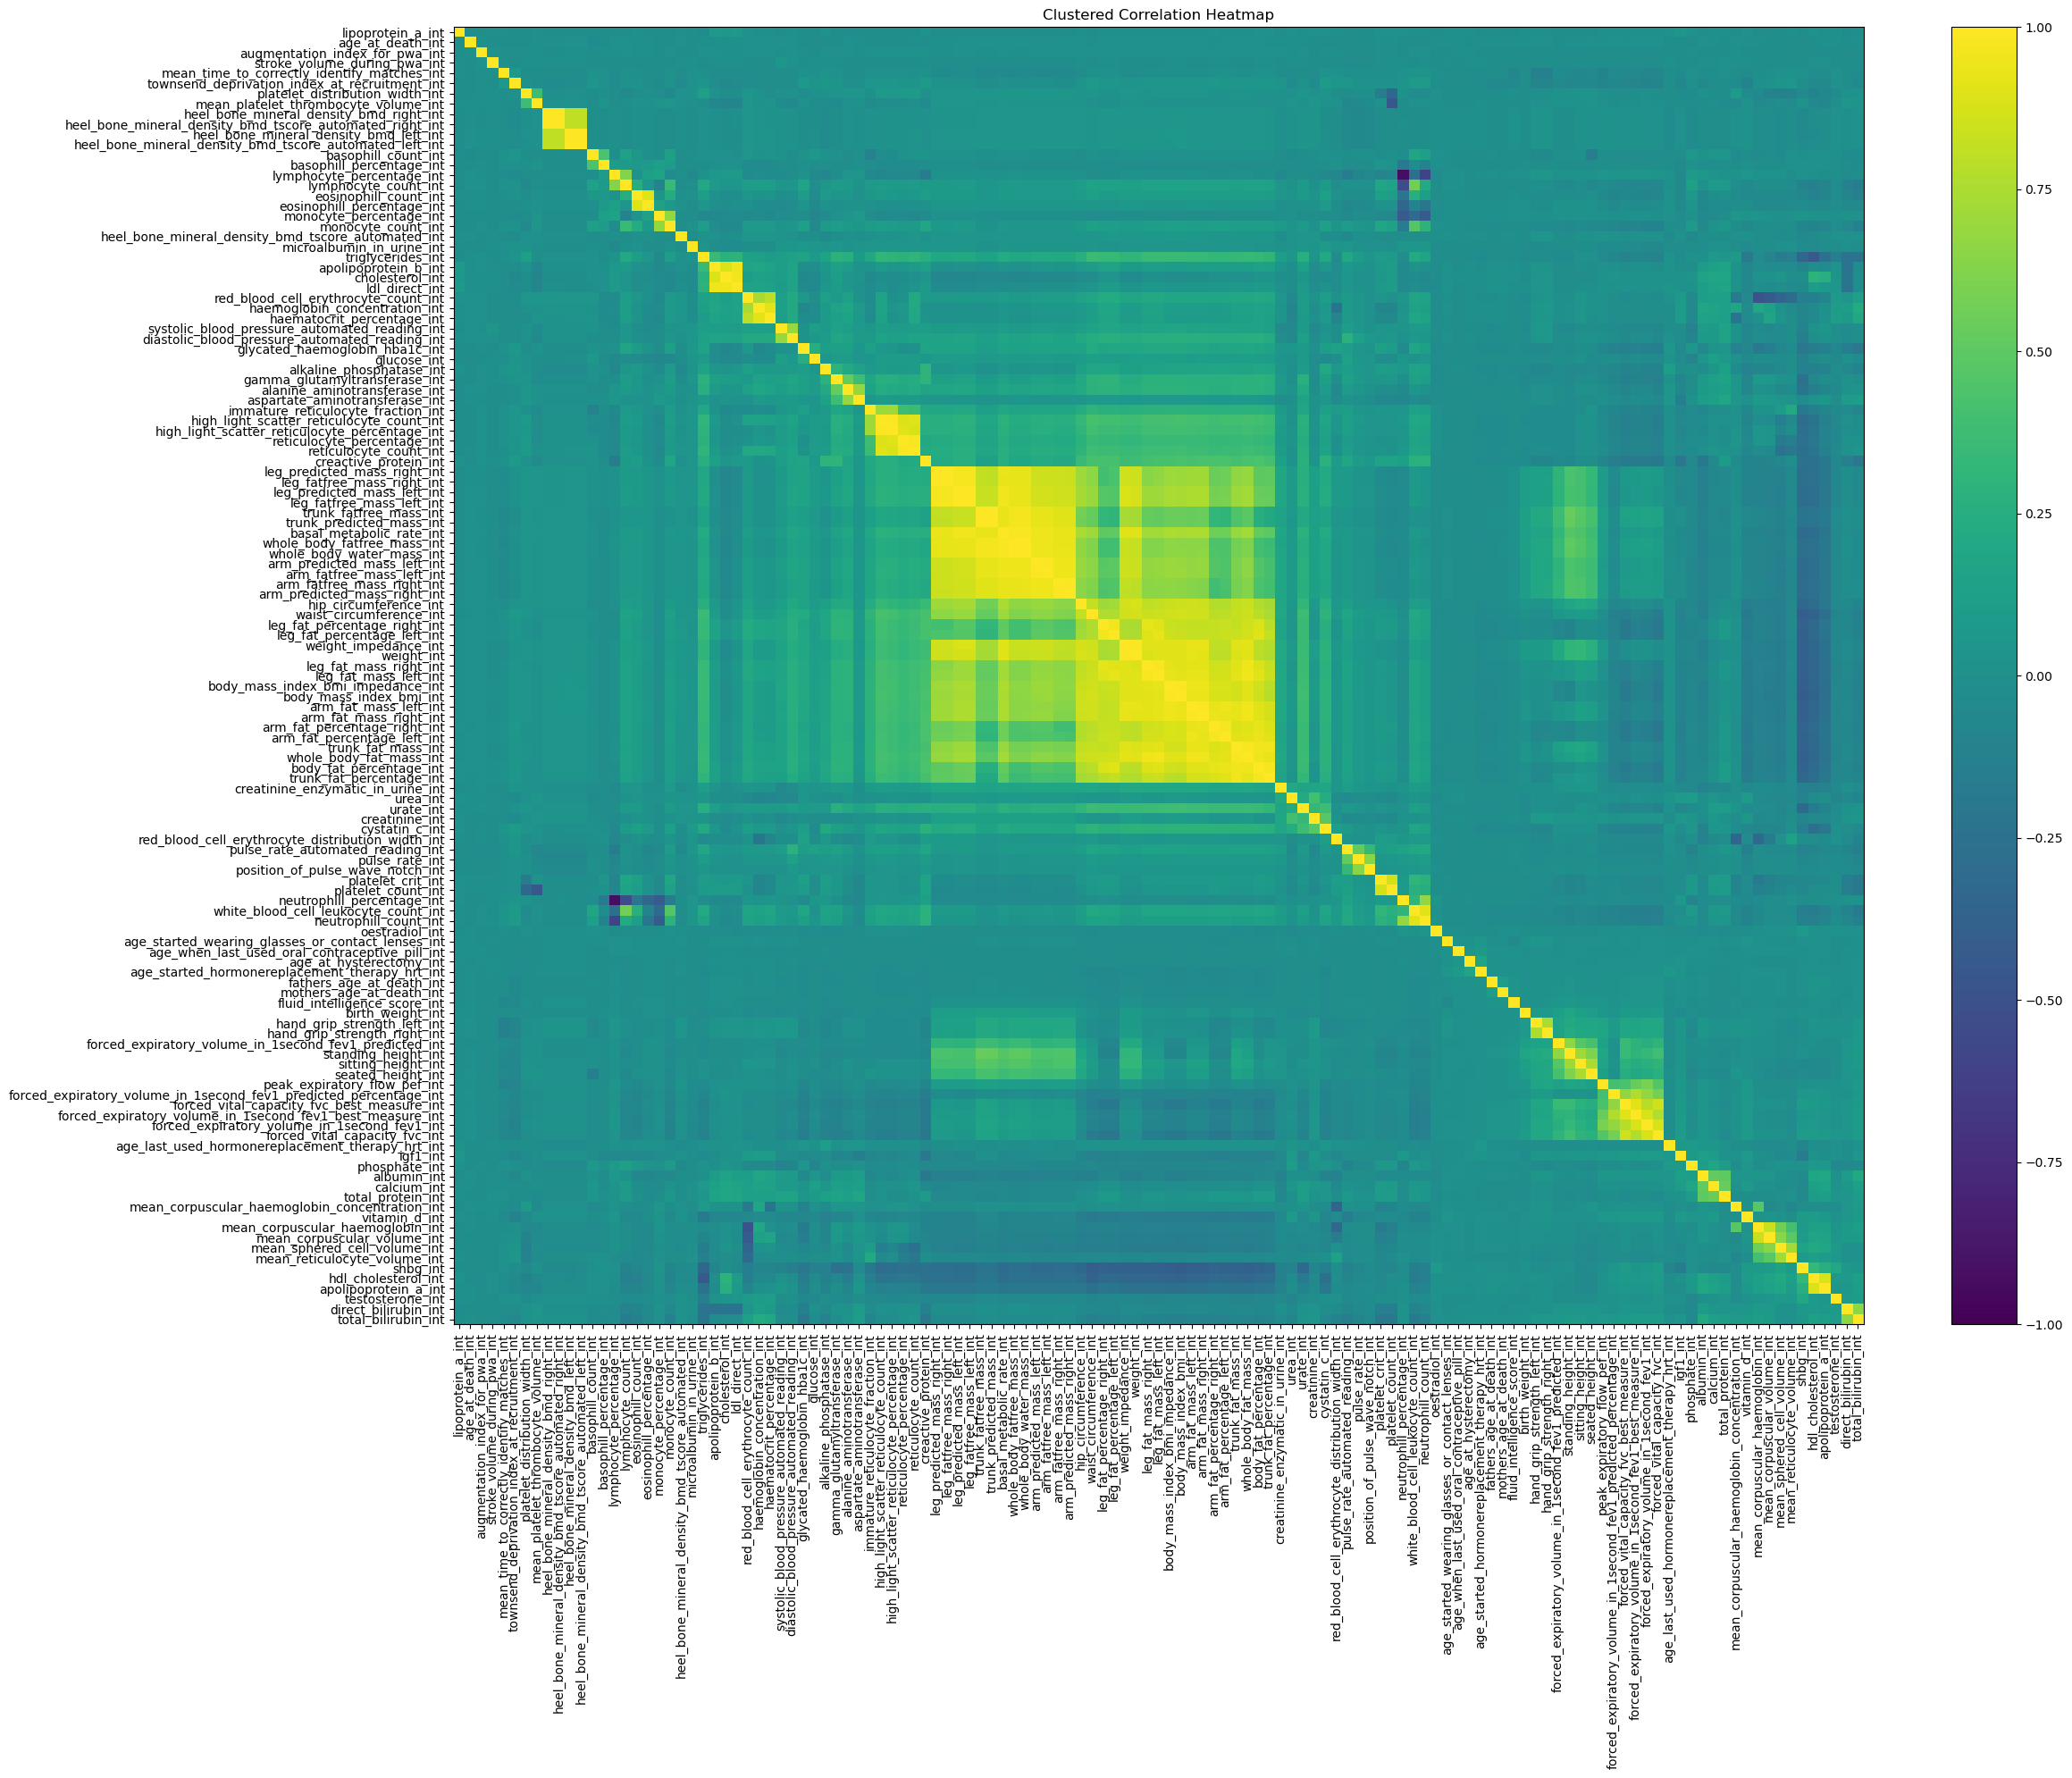

In [16]:
corr_df = (
    phenos.select(avail_phenos)
        .fill_nan(0)
        .fill_null(0)
        .corr()
)

labels = corr_df.columns
corr = corr_df.to_numpy()
corr = np.nan_to_num(corr, nan=0.0)   # guard against any NaNs from constant cols

# 2) Hierarchical clustering on correlation distance (1 - r)
dist_vec = squareform(1.0 - corr, checks=False)
Z = linkage(dist_vec, method="average")        # "single"/"complete"/"ward" also possible
order = leaves_list(Z)

corr_ord = corr[order][:, order]
labels_ord = [labels[i] for i in order]

# 3) Plot clustered heatmap
plt.figure(figsize=(25, 20))
im = plt.imshow(corr_ord, vmin=-1, vmax=1, aspect="auto")
plt.xticks(range(len(labels_ord)), labels_ord, rotation=90)
plt.yticks(range(len(labels_ord)), labels_ord)
plt.colorbar(im)
plt.title("Clustered Correlation Heatmap")
plt.tight_layout()
plt.show()


In [17]:
corr_df.with_columns(label = pl.Series(labels)).sort('triglycerides_int', descending=True)\
    .select('label', 'triglycerides_int').head(10)

label,triglycerides_int
str,f64
"""triglycerides_int""",1.0
"""waist_circumference_int""",0.36699
"""body_mass_index_bmi_int""",0.351465
"""body_mass_index_bmi_impedance_…",0.349266
"""leg_fat_mass_left_int""",0.347451
"""leg_fat_mass_right_int""",0.346696
"""apolipoprotein_b_int""",0.345609
"""leg_fat_percentage_left_int""",0.343426
"""whole_body_fat_mass_int""",0.343109


## Select training traits with minimal correlation 

In [18]:
seed_gene_df = significant_baseline
seed_gene_cts = seed_gene_df.group_by('phenotype').agg(pl.len()).sort('len', descending=True)
seed_gene_cts

phenotype,len
str,u64
"""standing_height_int""",111
"""sitting_height_int""",66
"""forced_vital_capacity_fvc_int""",49
"""mean_corpuscular_haemoglobin_i…",49
"""whole_body_fatfree_mass_int""",45
…,…
"""age_started_wearing_glasses_or…",1
"""age_at_hysterectomy_int""",1
"""creatinine_enzymatic_in_urine_…",1


In [19]:
seed_gene_df['region'].unique().len()

699

<Axes: >

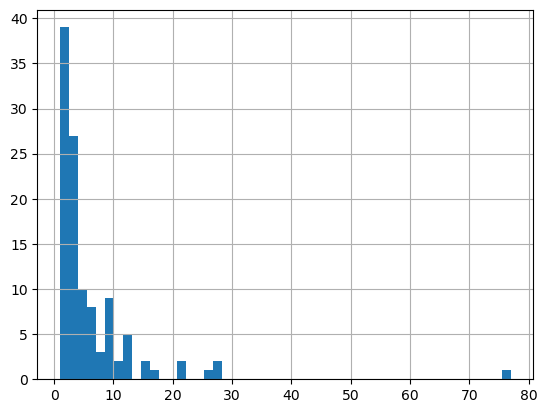

In [20]:
unique_genes_min_p = seed_gene_df.group_by('region').agg([
    pl.min('pval').alias('min_pval'),
    pl.col('phenotype').filter(pl.col('pval') == pl.min('pval')).first().alias('trait_with_min_pval')
]).sort('min_pval')#
unique_genes_min_p.group_by('trait_with_min_pval').agg(pl.len()).sort('len', descending=True)['len'].to_pandas().hist(bins = 50)

<Axes: >

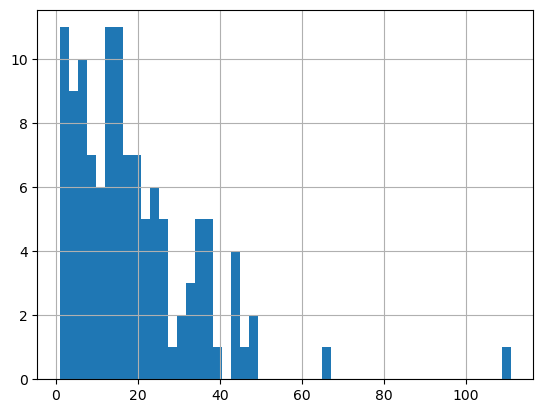

In [21]:
seed_gene_df.group_by('phenotype').agg(pl.len()).sort('len', descending=True)['len'].to_pandas().hist(bins = 50)

In [47]:
import numpy as np

def pick_representatives_from_corr(corr, labels, threshold=0.9, method="min_avg_abs_corr"):
    """
    corr: (n x n) numpy array (correlation matrix)
    labels: list/array of column names length n
    threshold: abs-correlation threshold to consider items 'connected'
    method: 'min_avg_abs_corr' or 'first'
    """
    n = corr.shape[0]
    # adjacency (ignore self loops)
    A = (np.abs(corr) >= threshold).astype(bool)
    np.fill_diagonal(A, False)

    # find connected components (BFS/DFS)
    visited = np.zeros(n, dtype=bool)
    components = []
    for i in range(n):
        if not visited[i]:
            stack = [i]
            comp = []
            visited[i] = True
            while stack:
                u = stack.pop()
                comp.append(u)
                nbrs = np.where(A[u])[0]
                for v in nbrs:
                    if not visited[v]:
                        visited[v] = True
                        stack.append(v)
            components.append(comp)

    keep_labels = []
    for comp in components:
        this_labels = [labels[i] for i in comp]
        this_labels = set(this_labels).intersection(set(seed_gene_cts['phenotype'].to_list()))
        if len(this_labels) == 0:
            continue
        # Sort Ascending (False) to get the LEAST associations
        # rep = seed_gene_cts.filter(pl.col('phenotype').is_in(this_labels)).sort('len', descending=True)['phenotype'][0]
        rep = seed_gene_cts.filter(pl.col('phenotype').is_in(this_labels)).sort('len')['phenotype'][0]

        keep_labels.append(rep)

    components = [[labels[i] for i in comp] for comp in components]
    return keep_labels, components

keep_labels,components = pick_representatives_from_corr(corr, labels, threshold=0.75)
print(len(keep_labels))
components

70


[['alkaline_phosphatase_int'],
 ['apolipoprotein_b_int', 'ldl_direct_int', 'cholesterol_int'],
 ['heel_bone_mineral_density_bmd_left_int',
  'heel_bone_mineral_density_bmd_tscore_automated_right_int',
  'heel_bone_mineral_density_bmd_tscore_automated_left_int',
  'heel_bone_mineral_density_bmd_right_int'],
 ['basophill_count_int'],
 ['white_blood_cell_leukocyte_count_int', 'neutrophill_count_int'],
 ['age_started_wearing_glasses_or_contact_lenses_int'],
 ['age_at_hysterectomy_int'],
 ['trunk_fatfree_mass_int',
  'arm_predicted_mass_right_int',
  'weight_int',
  'arm_fat_mass_right_int',
  'leg_fat_percentage_right_int',
  'body_mass_index_bmi_int',
  'body_mass_index_bmi_impedance_int',
  'leg_fat_percentage_left_int',
  'arm_fat_percentage_left_int',
  'trunk_fat_percentage_int',
  'whole_body_fat_mass_int',
  'arm_fat_mass_left_int',
  'leg_fat_mass_left_int',
  'leg_fat_mass_right_int',
  'trunk_fat_mass_int',
  'hip_circumference_int',
  'waist_circumference_int',
  'arm_fat_percen

## Select one phenotype per gene (only from the uncorrelated phenos)

In [48]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [49]:
oppg = (
    gene_trait_df
    .filter(pl.col('phenotype').is_in(keep_labels))
    .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    .unique(subset=["region"], keep="first", maintain_order=True)
)

print('Number of genes covered:', oppg.height)
oppg['phenotype'].value_counts(sort=True)

Number of genes covered: 579


phenotype,count
str,u64
"""standing_height_int""",83
"""mean_platelet_thrombocyte_volu…",28
"""sitting_height_int""",28
"""mean_corpuscular_volume_int""",23
"""cystatin_c_int""",20
…,…
"""lipoprotein_a_int""",1
"""stroke_volume_during_pwa_int""",1
"""creatinine_enzymatic_in_urine_…",1
